In [1]:
# Imports + Global Plot Settings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import seaborn as sns

# ---- Plot style ----
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# ---- Figure saving directory ----
FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIG_DIR.resolve())

Figure directory: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\results\figures


In [2]:
# Load processed dataset

DATA_PATH = Path("../data/processed/reviews_processed.csv")

df = pd.read_csv(DATA_PATH)

print("Loaded from:", DATA_PATH.resolve())
print("Shape:", df.shape)
print("Columns:", list(df.columns))

print("\nHead (rating, sentiment):")
print(df[["rating", "sentiment"]].head())

Loaded from: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\data\processed\reviews_processed.csv
Shape: (50000, 4)
Columns: ['review', 'rating', 'condition', 'sentiment']

Head (rating, sentiment):
   rating  sentiment
0       1          0
1       1          0
2       4          0
3       1          0
4       1          0


In [3]:
#  Dataset Snapshot Overview

print("===== DATASET SNAPSHOT =====")

print("\nTotal rows:", len(df))

# Unique conditions
if "condition" in df.columns:
    print("Unique conditions:", df["condition"].nunique())

# Missing rates
print("\nMissing values (counts):")
print(df.isna().sum())

print("\nMissing values (proportion):")
print(df.isna().mean())

# Review length statistics
df["char_len"] = df["review"].str.len()
df["word_len"] = df["review"].str.split().str.len()

print("\nReview length (characters):")
print("Mean:", round(df["char_len"].mean(), 2))
print("Median:", df["char_len"].median())

print("\nReview length (words):")
print("Mean:", round(df["word_len"].mean(), 2))
print("Median:", df["word_len"].median())

print("============================")

===== DATASET SNAPSHOT =====

Total rows: 50000
Unique conditions: 713

Missing values (counts):
review         0
rating         0
condition    251
sentiment      0
dtype: int64

Missing values (proportion):
review       0.00000
rating       0.00000
condition    0.00502
sentiment    0.00000
dtype: float64

Review length (characters):
Mean: 448.81
Median: 446.0

Review length (words):
Mean: 84.55
Median: 84.0


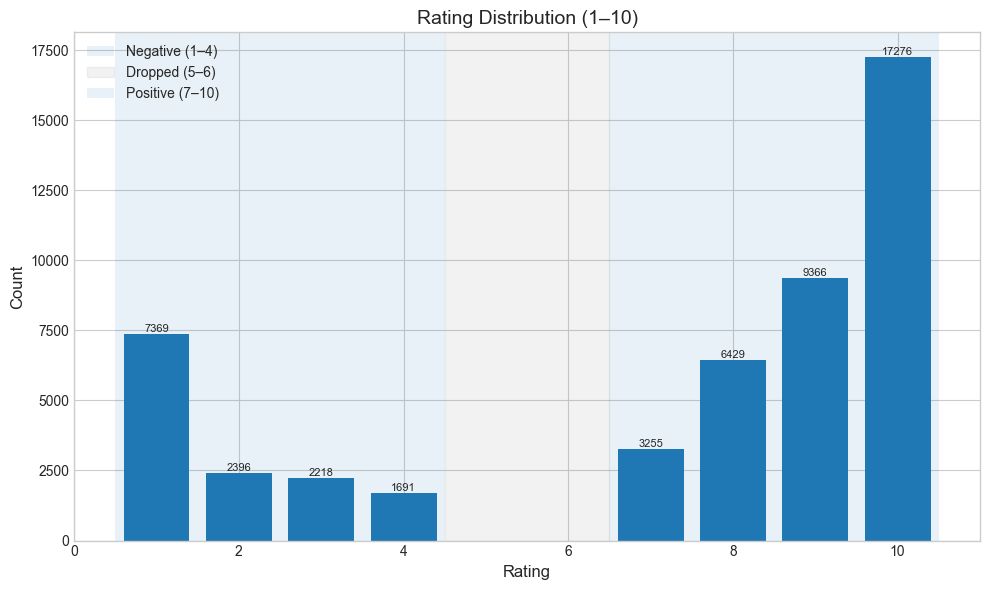

In [5]:
# Rating Distribution (1–10)

rating_counts = df["rating"].value_counts().sort_index()

plt.figure()

bars = plt.bar(rating_counts.index, rating_counts.values)

plt.title("Rating Distribution (1–10)")
plt.xlabel("Rating")
plt.ylabel("Count")

# Shade regions
plt.axvspan(0.5, 4.5, alpha=0.1, label="Negative (1–4)")
plt.axvspan(4.5, 6.5, alpha=0.1, color='grey', label="Dropped (5–6)")
plt.axvspan(6.5, 10.5, alpha=0.1, label="Positive (7–10)")

# Annotate counts
for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v, str(v),
             ha='center', va='bottom', fontsize=8)

plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "fig_rating_distribution.png", dpi=300)
plt.show()

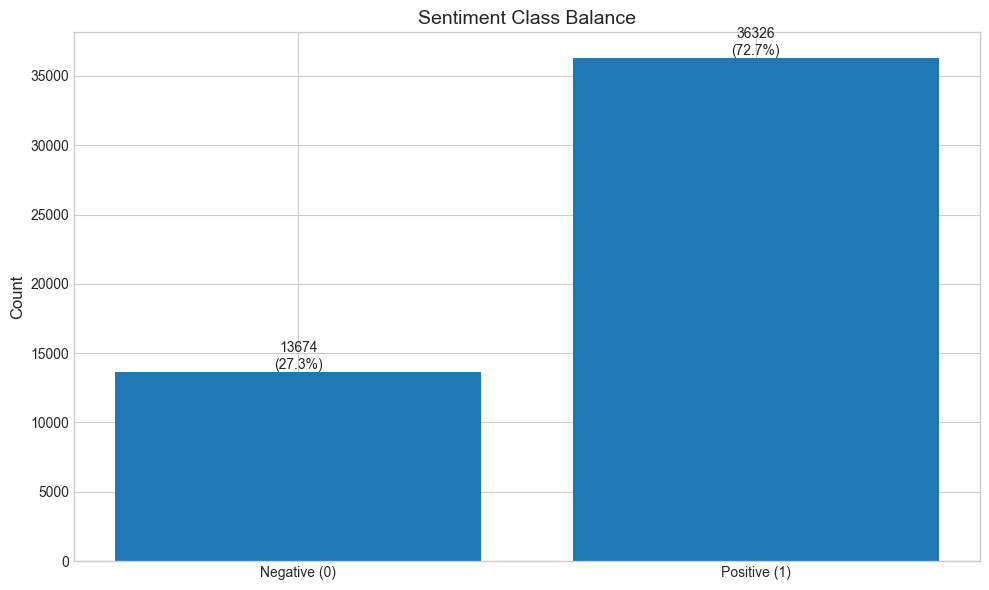

In [6]:
#  Sentiment Balance (Count + Percent)

sent_counts = df["sentiment"].value_counts().sort_index()
sent_props = df["sentiment"].value_counts(normalize=True).sort_index()

labels = ["Negative (0)", "Positive (1)"]

plt.figure()

bars = plt.bar(labels, sent_counts.values)

plt.title("Sentiment Class Balance")
plt.ylabel("Count")

# count + percent labels
for i, v in enumerate(sent_counts.values):
    percent = round(sent_props.values[i] * 100, 1)
    plt.text(i, v, f"{v}\n({percent}%)",
             ha='center', va='bottom')

plt.tight_layout()

plt.savefig(FIG_DIR / "fig_sentiment_balance.png", dpi=300)
plt.show()

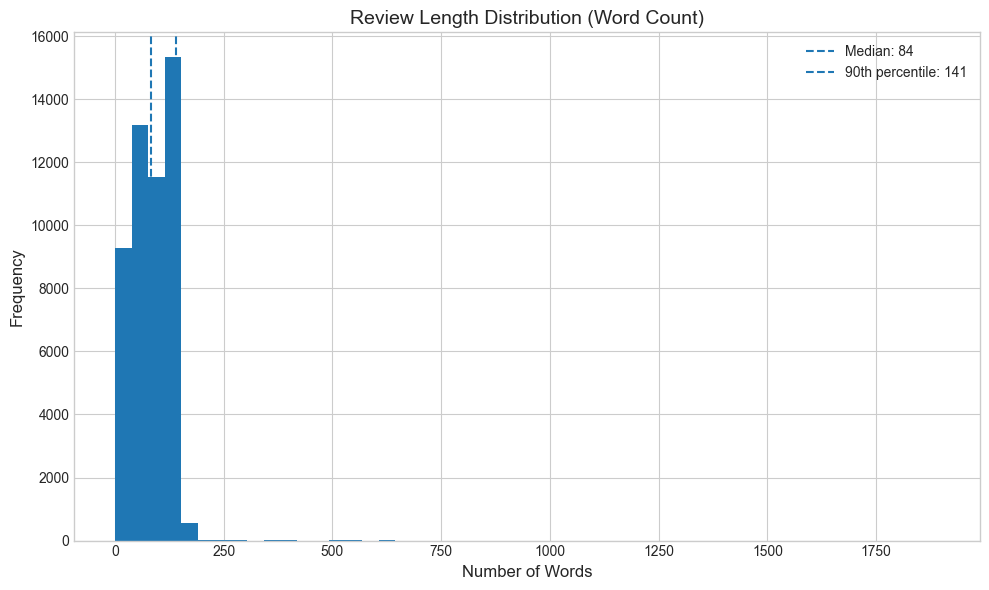

Median word length: 84.0
90th percentile: 141.0


In [7]:
# Review Length Distribution (Word Count)

word_len = df["word_len"]

plt.figure()

plt.hist(word_len, bins=50)

plt.title("Review Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

# Median and 90th percentile
median_val = word_len.median()
p90_val = word_len.quantile(0.90)

plt.axvline(median_val, linestyle='--', label=f"Median: {int(median_val)}")
plt.axvline(p90_val, linestyle='--', label=f"90th percentile: {int(p90_val)}")

plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "fig_review_length.png", dpi=300)
plt.show()

print("Median word length:", median_val)
print("90th percentile:", p90_val)

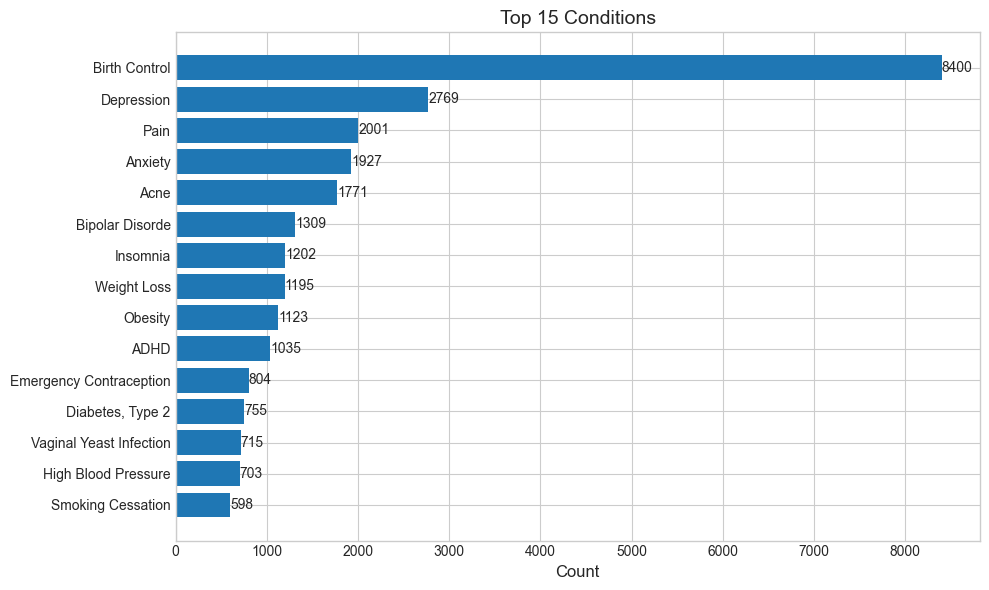

In [8]:
# Top 15 Conditions

top_conditions = (
    df["condition"]
    .dropna()
    .value_counts()
    .head(15)
)

plt.figure()

bars = plt.barh(top_conditions.index[::-1], top_conditions.values[::-1])

plt.title("Top 15 Conditions")
plt.xlabel("Count")

# Add count labels
for i, v in enumerate(top_conditions.values[::-1]):
    plt.text(v, i, str(v), va='center')

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_top_conditions.png", dpi=300)
plt.show()

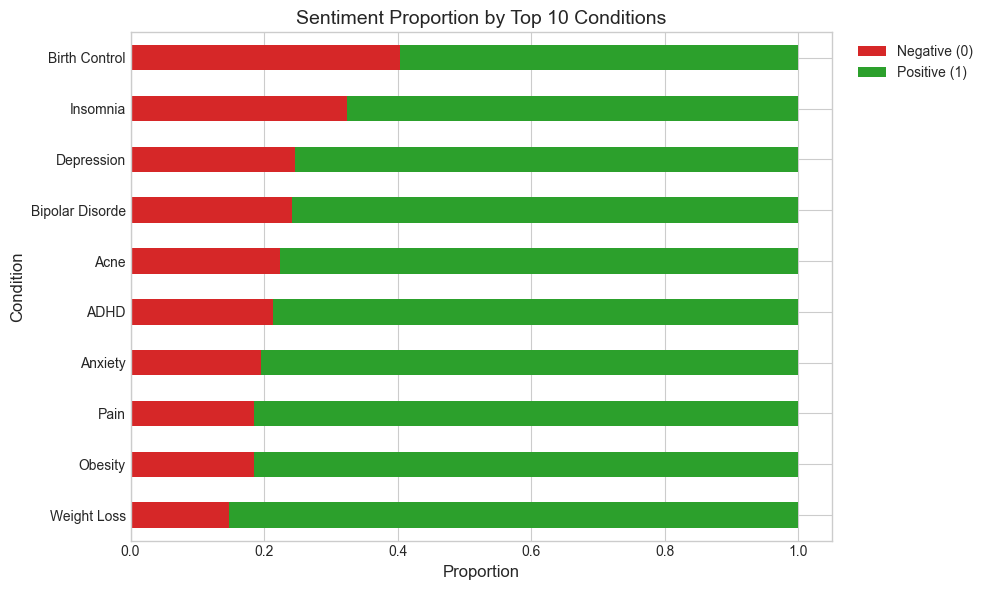

In [10]:
# Sentiment proportion per top 10 conditions 

top10 = (
    df["condition"]
    .dropna()
    .value_counts()
    .head(10)
    .index
)

subset = df[df["condition"].isin(top10)].copy()

cond_sent = (
    subset.groupby(["condition", "sentiment"])
    .size()
    .unstack()
)

# Convert to proportions
cond_sent_prop = cond_sent.div(cond_sent.sum(axis=1), axis=0)

# Sort by negative proportion for visual clarity
cond_sent_prop = cond_sent_prop.sort_values(by=0)

plt.figure(figsize=(10, 6))

cond_sent_prop.plot(
    kind="barh",
    stacked=True,
    color=["#d62728", "#2ca02c"],   # Red (negative) / Green (positive)
    ax=plt.gca()
)

plt.title("Sentiment Proportion by Top 10 Conditions")
plt.xlabel("Proportion")
plt.ylabel("Condition")

# Move legend outside
plt.legend(
    ["Negative (0)", "Positive (1)"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_condition_sentiment_proportions.png", dpi=300)
plt.show()

In [11]:
# 5 Example Reviews (Raw)

sample_examples = df.sample(5, random_state=42)

display(sample_examples[["rating", "sentiment", "condition", "review"]])

,rating,sentiment,condition,review
33553,10,1,Osteoarthritis,"""The Best."""
9427,2,0,Birth Control,"""I've had this medication for almost 5 months ..."
199,1,0,Depression,"""This drug is not for me. Not only did I have ..."
12447,2,0,Birth Control,"""I changed from Yaz to the Nuvaring as I liked..."
39489,8,1,Insomnia,"""I have been taking melatonin every night for ..."
